In [1]:
import os
import sys
import yaml
import copy
import time
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [4]:
cmap = gu.precip_cmap(return_rgb=False, land_map=False)

In [5]:
from scipy.stats import t as student_t  # <-- define at module scope

def corr_pvalue(da_x: xr.DataArray, da_y: xr.DataArray, dim: str):
    r = xr.corr(da_x, da_y, dim=dim)

    n = xr.where(np.isfinite(da_x) & np.isfinite(da_y), 1, 0).sum(dim)
    df = n - 2

    denom = xr.where((1.0 - r**2) > 0, (1.0 - r**2), np.nan)

    tstat = r * xr.apply_ufunc(
        np.sqrt,
        df / denom,
        dask="parallelized",
        output_dtypes=[np.float64],
    )

    # use a top-level function (no missing 'stats' inside workers)
    def pval_func(tstat_np, df_np):
        return 2.0 * student_t.sf(np.abs(tstat_np), df_np)

    p = xr.apply_ufunc(
        pval_func,
        tstat, df,
        dask="parallelized",
        output_dtypes=[np.float64],
    ).where(df > 0)

    return r, p

In [ ]:
save_dir = f'/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/'

In [ ]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax.zarr'
ds_ERA5_default = xr.open_zarr(fn)

## Inter-annual

### EMOS

In [11]:
fn_EMOS_T2 = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/T2_EMOS_calib.zarr'
fn_EMOS_TMAX = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/TMAX_EMOS_calib.zarr'
# fn_EMOS_TMIN = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/TMIN_EMOS_calib.zarr'

ds_T2 = xr.open_zarr(fn_EMOS_T2)[['emos_mu']].rename({'emos_mu': 'TREFHT'})
ds_TMAX = xr.open_zarr(fn_EMOS_TMAX)[['emos_mu']].rename({'emos_mu': 'TREFHTMX'})
# ds_TMIN = xr.open_zarr(fn_EMOS_TMIN)[['emos_mu']].rename({'emos_mu': 'TREFHTMN'})

ds_EMOS = xr.merge([ds_T2, ds_TMAX]) # , ds_TMIN
lead_year = ds_EMOS.lead_time // 365

ds_max  = ds_EMOS[["TREFHTMX"]].groupby(lead_year.rename("lead_year")).max("lead_time")
ds_mean = ds_EMOS[["TREFHT"]].groupby(lead_year.rename("lead_year")).mean("lead_time")

ds_max = ds_max.rename({'TREFHTMX': 'TREFHTMX_max'})
ds_mean = ds_mean.rename({'TREFHT': 'TREFHT_mean'})
ds_EMOS_yearly  = xr.merge([ds_max, ds_mean])

chunks = []
for ly in ds_EMOS_yearly.lead_year.values:
    chunk = ds_EMOS_yearly.sel(lead_year=ly)
    valid_years = chunk.init_time.values + int(ly)
    chunk = chunk.assign_coords(valid_year=("init_time", valid_years))
    chunk = chunk.swap_dims({"init_time": "valid_year"}).drop_vars("init_time")
    chunks.append(chunk.expand_dims(lead_year=[int(ly)]))

ds_out = xr.concat(chunks, dim="lead_year")
ds_out = ds_out.reindex(valid_year=np.arange(ds_out.valid_year.min(), ds_out.valid_year.max() + 1))
ds_out = ds_out.chunk({"valid_year": -1, "lead_year": -1, "lat": 192, "lon": 288})

In [12]:
ds_CESM = ds_CESM_default = ds_out
vars_ = list(ds_CESM.keys())
ds_ERA5 = ds_ERA5_default[vars_]


ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_all = xr.concat(ds_collection, dim='lead_year')

In [72]:
save_name = save_dir + 'CESM_EMOS_minmax.zarr'
# ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_EMOS_minmax.zarr


### BMA

In [19]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/T2_BMA_calib.zarr'

fn_BMA_T2 = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/T2_BMA_calib.zarr'
fn_BMA_TMAX = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/TMAX_BMA_calib.zarr'

ds_T2 = xr.open_zarr(fn_BMA_T2)[['bma_mu']].rename({'bma_mu': 'TREFHT'})
ds_TMAX = xr.open_zarr(fn_BMA_TMAX)[['bma_mu']].rename({'bma_mu': 'TREFHTMX'})
ds_BMA = xr.merge([ds_T2, ds_TMAX])

lead_year = ds_BMA.lead_time // 365

ds_max  = ds_BMA[["TREFHTMX"]].groupby(lead_year.rename("lead_year")).max("lead_time")
ds_mean = ds_BMA[["TREFHT"]].groupby(lead_year.rename("lead_year")).mean("lead_time")

ds_max = ds_max.rename({'TREFHTMX': 'TREFHTMX_max'})
ds_mean = ds_mean.rename({'TREFHT': 'TREFHT_mean'})
ds_BMA_yearly  = xr.merge([ds_max, ds_mean])

chunks = []
for ly in ds_BMA_yearly.lead_year.values:
    chunk = ds_BMA_yearly.sel(lead_year=ly)
    valid_years = chunk.init_time.values + int(ly)
    chunk = chunk.assign_coords(valid_year=("init_time", valid_years))
    chunk = chunk.swap_dims({"init_time": "valid_year"}).drop_vars("init_time")
    chunks.append(chunk.expand_dims(lead_year=[int(ly)]))

ds_out = xr.concat(chunks, dim="lead_year")
ds_out = ds_out.reindex(valid_year=np.arange(ds_out.valid_year.min(), ds_out.valid_year.max() + 1))
ds_out = ds_out.chunk({"valid_year": -1, "lead_year": -1, "lat": 192, "lon": 288})

In [20]:
ds_CESM = ds_CESM_default = ds_out
vars_ = list(ds_CESM.keys())
ds_ERA5 = ds_ERA5_default[vars_]


ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_all = xr.concat(ds_collection, dim='lead_year')

In [24]:
save_name = save_dir + 'CESM_BMA_minmax.zarr'
ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_BMA_minmax.zarr


In [21]:
test = ds_ACC_all['TREFHT_mean'].isel(lead_year=-1).values

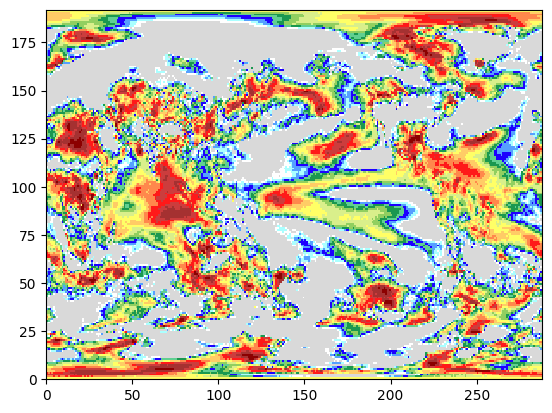

In [22]:
plt.pcolormesh(test, vmin=0, vmax=1.0, cmap=cmap)

In [23]:
test.mean()

0.20762023

**Compare with CESM Raw**

In [65]:
ds_raw = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_ACC.zarr')
test_raw = ds_raw['TREFHT_mean'].isel(lead_year=-1).values

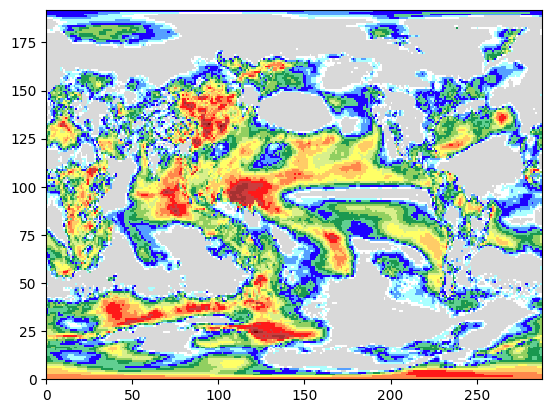

In [67]:
plt.pcolormesh(test_raw, vmin=0, vmax=1.0, cmap=cmap)

In [68]:
test_raw.mean()

0.14229396

### Detrend

In [8]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_detrend.zarr'
ds_CESM_detrend = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_detrend.zarr'
ds_ERA5_detrend = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_detrend
ds_CESM = ds_CESM_detrend

ds_ERA5 = ds_ERA5.rename({'year': 'valid_year'})
varnames = list(ds_ERA5.keys())

ds_collection = []

for i_lead in range(10):
    ds_CESM_slice = ds_CESM.isel(lead_year=i_lead)
    
    # align two datasets
    ds_ERA5_slice = ds_ERA5
    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_slice, join="inner")
    
    # compute ACC if there's enough time values
    if len(ds_CESM_slice['valid_year']) >= 10:
        
        out_vars = {}
        for varname in varnames:
            r, p = corr_pvalue(ds_CESM_slice[varname], ds_ERA5_slice[varname], dim="valid_year")
            out_vars[varname] = r
            out_vars[f"{varname}_pval"] = p
            
        ds_out = xr.Dataset(out_vars).expand_dims(lead_year=[i_lead])
        ds_collection.append(ds_out)

ds_ACC_detrend = xr.concat(ds_collection, dim='lead_year')

In [9]:
ds_ACC_detrend = ds_ACC_detrend.load()

In [10]:
save_name = save_dir + 'CESM_minmax_ACC_detrend.zarr'
# ds_ACC_detrend.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_ACC_detrend.zarr


## Decadal

### Default

In [4]:
save_dir = f'/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/'

In [5]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_10Y.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

varnames = list(ds_ERA5.keys())

out_vars = {}
for varname in varnames:
    r, p = corr_pvalue(ds_CESM[varname], ds_ERA5[varname], dim="init_year")
    out_vars[varname] = r
    out_vars[f"{varname}_pval"] = p
            
ds_ACC_all = xr.Dataset(out_vars)

In [7]:
save_name = save_dir + 'CESM_minmax_10Y_ACC.zarr'
# ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_ACC.zarr


### Detrend

In [11]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_detrend.zarr'
ds_CESM_default = xr.open_zarr(fn)

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/ERA5_minmax_10Y_detrend.zarr'
ds_ERA5_default = xr.open_zarr(fn)

ds_ERA5 = ds_ERA5_default
ds_CESM = ds_CESM_default

varnames = list(ds_ERA5.keys())

out_vars = {}
for varname in varnames:
    r, p = corr_pvalue(ds_CESM[varname], ds_ERA5[varname], dim="init_year")
    out_vars[varname] = r
    out_vars[f"{varname}_pval"] = p
            
ds_ACC_all = xr.Dataset(out_vars)

In [12]:
save_name = save_dir + 'CESM_minmax_10Y_detrend_ACC.zarr'
# ds_ACC_all.to_zarr(save_name, mode='w')
print(save_name)

/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_detrend_ACC.zarr
